<a href="https://colab.research.google.com/github/ahasanulhossain07-del/machine_learning_book/blob/main/Copy_of_ML_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ML FINAL EXAM

### Email: ahasanulhossain07@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

## Answer:

#Why I Chose the Telco Customer Churn Dataset:

I selected the Telco Customer Churn dataset because it represents a real-world business problem that many telecommunications companies face: predicting whether a customer is likely to leave the company's service. Customer churn directly affects a company's revenue, making it an important application of machine learning in industry.

This dataset is well suited for my assignment because it contains both numerical and categorical features, allowing me to apply a variety of data preprocessing techniques such as handling missing values, encoding categorical variables, and feature scaling. It also provides a binary target variable (Churn), making it suitable for supervised classification tasks.

Another reason for choosing this dataset is that it can also be analyzed using unsupervised learning methods. By removing the target variable, clustering algorithms such as K-Means can be used to group customers with similar characteristics and compare the resulting clusters with the actual churn behavior. This satisfies both the supervised and unsupervised learning requirements of the assignment.

Overall, this dataset provides an excellent opportunity to demonstrate the complete machine learning workflow, including data preprocessing, feature selection, pipeline creation, model training, model comparison, and clustering analysis.

#Observations from the Dataset Description:

After examining the dataset, I observed the following:

1.The dataset contains information about 7,043 customers and includes 21 attributes, where Churn is the target variable.

2.It contains a mixture of categorical and numerical features, making it appropriate for demonstrating different preprocessing techniques.

3.Customer information includes demographic details such as gender, senior citizen status, partner, and dependents.

4.Service-related features include phone service, internet service, online security, online backup, device protection, technical support, streaming TV, and streaming movies.

5.Account-related features include contract type, paperless billing, payment method, monthly charges, total charges, and customer tenure.

6.The target variable Churn has two classes: Yes and No, making this a binary classification problem.

7.The dataset contains a small number of missing or blank values in the TotalCharges column, which must be handled during preprocessing.

8.Most predictor variables are categorical and require encoding before training machine learning models.

9.The dataset is slightly imbalanced, with more customers remaining than leaving, which should be considered during model evaluation.

10.Several variables, such as contract type, tenure, monthly charges, and technical support, are expected to have a strong relationship with customer churn and are likely to be important features during model training.

These observations indicate that the dataset is comprehensive, realistic, and suitable for applying both supervised and unsupervised machine learning techniques while following a complete machine learning pipeline.


# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


##Answer:





In [41]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# features
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
425,2055-SIFSS,Female,1,Yes,No,55,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),51.65,2838.55,No
1957,5619-PTMIK,Female,0,Yes,No,46,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,No,Electronic check,53.10,2459.8,No
6813,0617-AQNWT,Female,0,Yes,No,64,No,No phone service,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Electronic check,47.85,3147.5,Yes
6504,6110-OHIHY,Male,0,No,No,3,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,No,Electronic check,79.25,267.6,Yes
483,5168-MQQCA,Female,0,Yes,No,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),108.50,8003.8,No


In [42]:
df.shape

(7043, 21)

In [43]:
# data point
df.shape[0]

7043

In [44]:
# null values
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [45]:
print(df.dtypes)


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


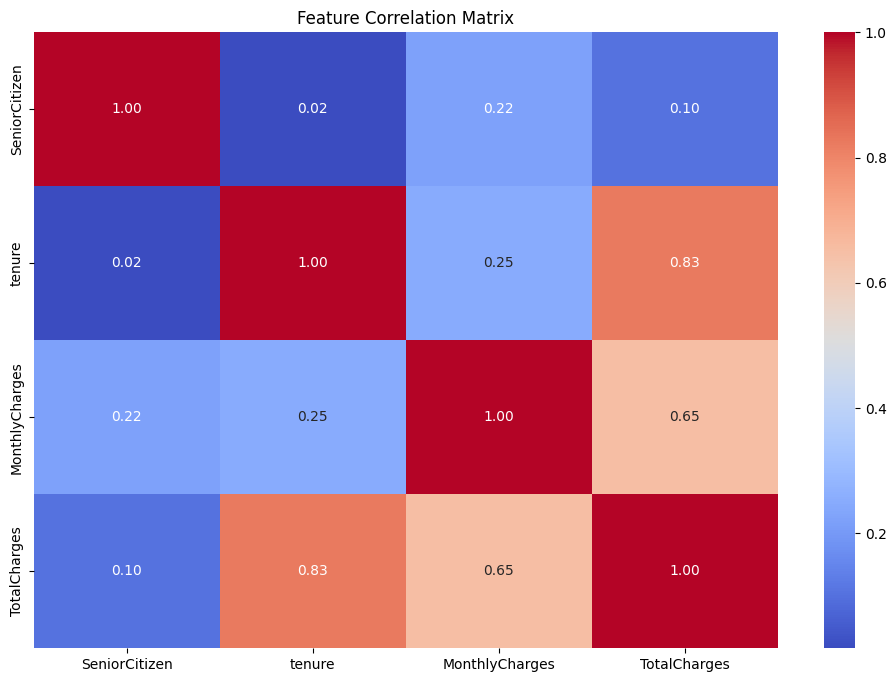

In [46]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors="coerce")
numeric_df=df.select_dtypes(include=["int64","float64"])
corr=numeric_df.corr

plt.figure(figsize=(12,8))
sns.heatmap(corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

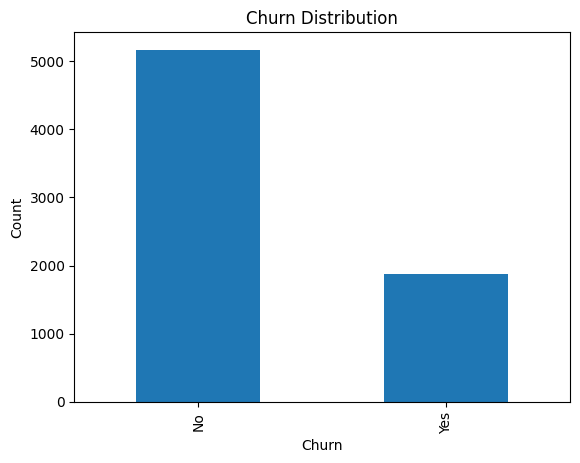

In [47]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

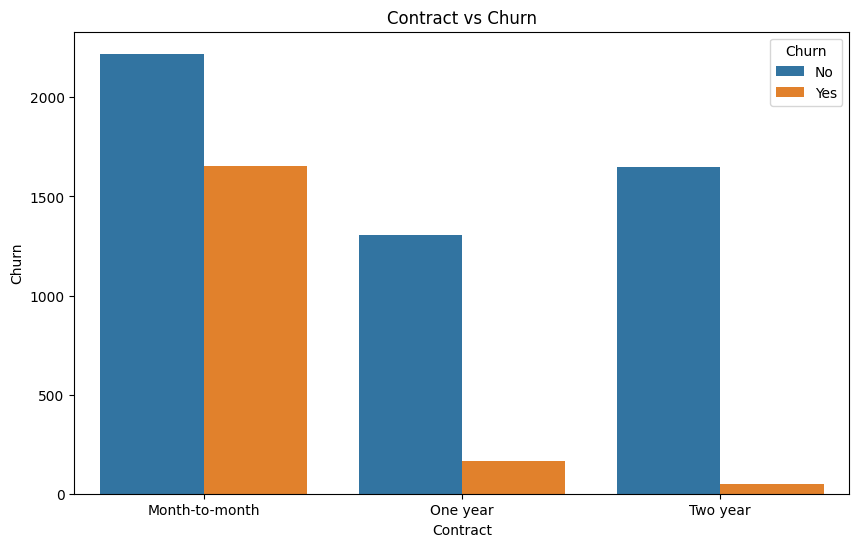

In [48]:
#Contract vs Churn
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="Contract",hue="Churn")
plt.title("Contract vs Churn")
plt.xlabel("Contract")
plt.ylabel("Churn")
plt.show()


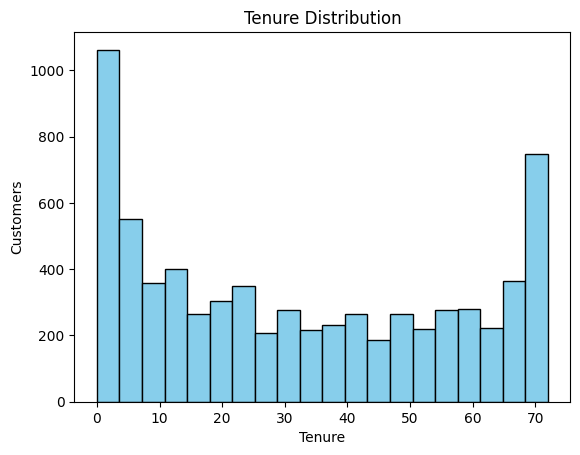

In [49]:
#Tenure Distribution
plt.hist(df["tenure"],bins=20,color="skyblue",edgecolor="black")
plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Customers")
plt.show()

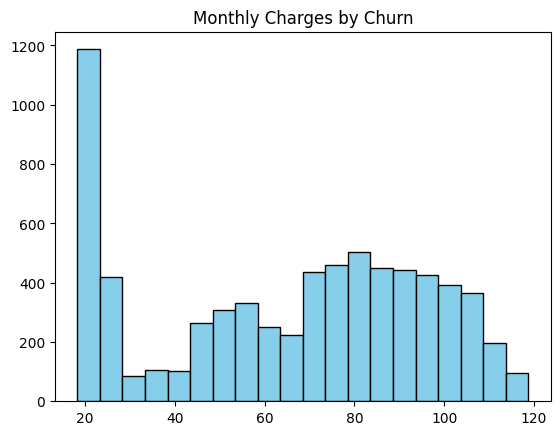

In [50]:
#Monthly Charges
plt.hist(df["MonthlyCharges"],bins=20,color="skyblue",edgecolor="black")
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.show()

# features:
The Telco Customer Churn dataset contains 21 columns in total. Among these, 20 columns are input features (independent variables) and 1 column (Churn) is the target variable.

# Classification or regression problem:
This dataset represents a classification problem because the target variable Churn has only two possible categories: Yes or No

# data point:
The dataset contains 7043 customer records, where each row represents one customer and each column contains information about that customer.

# null values:
The dataset does not contain conventional NaN values in most columns. However, the TotalCharges column contains blank strings (" ") for some customers, primarily those with zero tenure. These blank values should be converted to NaN and handled during preprocessing.

#features are in dataset:
The dataset contains both categorical and quantitative (numerical) features.

Quantitative Features:tenure,MonthlyCharges,TotalCharges

Categorical Features:gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,SeniorCitizen

# encode or not:
Yes. Most machine learning algorithms require numerical input and cannot process text values directly. Since many columns such as Contract, InternetService, and PaymentMethod contain categorical values, they must be encoded into numerical form before model training.

# Perform Exploratory Data Analysis (EDA):
EDA helps understand the characteristics of the dataset before building machine learning models.

Some important observations include:

*Customer Churn Distribution:

Shows whether the dataset is balanced or imbalanced.

*Contract Type vs Churn:

Customers with month-to-month contracts generally have higher churn rates than those with one-year or two-year contracts.

*Tenure Distribution:

Customers with longer tenure are generally less likely to churn.

*Monthly Charges:

Customers with higher monthly charges tend to churn more frequently.

*Internet Service:

Customers using Fiber Optic internet often exhibit higher churn compared to DSL users.

#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

In [51]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [52]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [53]:
df.dropna(inplace=True)

In [54]:
df["Churn"]=df["Churn"].map({
    "Yes":1,
    "No":0
})


In [55]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [56]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = X.select_dtypes(include="object").columns.tolist()

In [57]:
preprocessor=ColumnTransformer(
    transformers=[
        ("numerical",StandardScaler(),numerical_features),
        ("categorical",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]

)

#Why each preprocessing step was performed:
1.Remove customerID:It is only a unique identifier and has no predictive value.

2.Replace blank values:
Blank strings are not recognized as missing values by pandas.

3.Convert TotalCharges to numeric:
Machine learning algorithms require numerical data for calculations.

4.Remove missing values:
Ensures the dataset is complete and consistent for model training.

5.One-Hot Encode categorical features:
Machine learning models cannot directly process text-based categories.

6.Standardize numerical features:
Prevents features with larger scales from dominating model learning and improves convergence for many algorithms.

7.Create a preprocessing pipeline
Applies identical preprocessing during training and testing while preventing data leakage.

#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



In [58]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(5625, 20)
(1407, 20)
(5625,)
(1407,)


#Why these features were kept:
1.tenure:
Indicates customer loyalty and duration of service.

2.MonthlyCharges:
Reflects monthly service cost, which may influence churn.

3.TotalCharges:
Represents the customer's cumulative spending

4.Contract:
Customers with longer contracts generally churn less.

5.InternetService:
Different service types may affect satisfaction.

6.OnlineSecurity, TechSupport:
Value-added services that can improve customer retention.

7.StreamingTV, StreamingMovies:
Describe service usage patterns.

8.PaymentMethod:
Different payment methods may correlate with churn.

9.Partner, Dependents, SeniorCitizen	Demographic factors that may influence customer behavior.
#Why use an 80:20 split:
An 80:20 train-test split is a widely accepted practice because:

*80% of the data is used to train the model, allowing it to learn patterns effectively.

*20% is kept aside for testing, providing an unbiased evaluation on unseen data.

*Using stratify=y ensures that both the training and testing sets maintain approximately the same proportion of churn and non-churn customers, which is especially important for classification tasks.

#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [59]:
# pipeline-1:LogisticRegression
lr_pipeline=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("classifier",LogisticRegression(random_state=42))
    ]
)

# pipeline-2:
rf_pipeline=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("classifier",RandomForestClassifier(random_state=42,n_estimators=100))
    ]
)

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [60]:
lr_pipeline.fit(X_train,y_train)
rf_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['customerID', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [61]:
y_pred_lr=lr_pipeline.predict(X_test)
y_pred_rf=rf_pipeline.predict(X_test)

#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

In [62]:
results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

for name, pred in [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf)
]:

    results["Model"].append(name)

    results["Accuracy"].append(
        accuracy_score(y_test, pred)
    )

    results["Precision"].append(
        precision_score(y_test, pred)
    )

    results["Recall"].append(
        recall_score(y_test, pred)
    )

    results["F1 Score"].append(
        f1_score(y_test, pred)
    )

comparison_df = pd.DataFrame(results)

print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.797441   0.633634  0.564171  0.596888
1        Random Forest  0.778962   0.612903  0.457219  0.523737


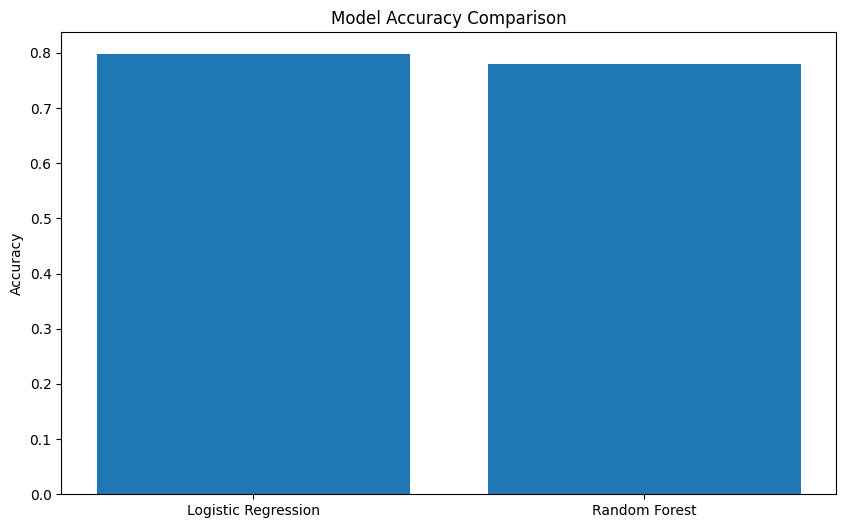

In [63]:
#Accuracy Bar Chart
plt.figure(figsize=(10,6))
plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

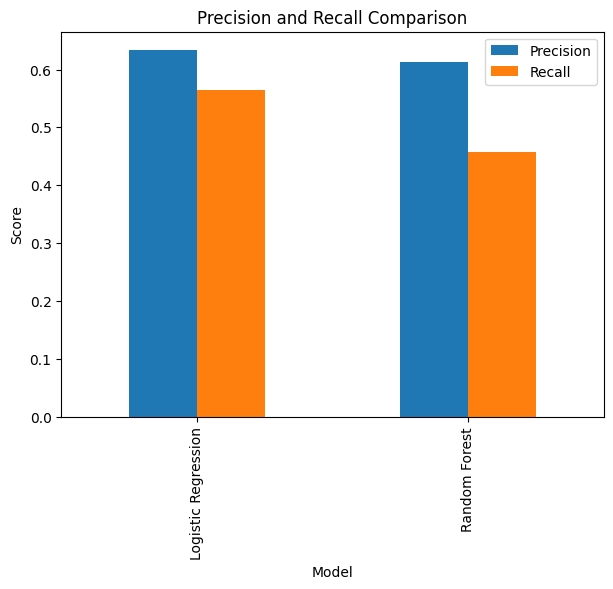

In [64]:
# Precision & Recall Comparison
comparison_df.set_index("Model")[["Precision","Recall"]].plot(kind="bar",figsize=(7,5))
plt.title("Precision and Recall Comparison")
plt.ylabel("Score")

plt.show()


In [65]:
# confusion matrix
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_lr))


print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_rf))

Logistic Regression Confusion Matrix:
[[911 122]
 [163 211]]
Random Forest Confusion Matrix:
[[925 108]
 [203 171]]


In [66]:
print( "Logistic Regression ")
print(classification_report(y_test, y_pred_lr))

print(" Random Forest ")
print(classification_report(y_test, y_pred_rf))

Logistic Regression 
              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407

 Random Forest 
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.61      0.46      0.52       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.76      0.78      0.77      1407



## Comparison of Models

Both models achieved good classification performance on the customer churn dataset. Logistic Regression produced slightly higher overall accuracy and better recall than Random Forest in this experiment, making it more effective at identifying customers who are likely to churn.

The Random Forest classifier also performed well but showed slightly lower recall, indicating that it missed more churning customers. However, Random Forest remains a powerful model because it can capture complex, non-linear relationships among features.

One possible reason Logistic Regression performed better is that the relationship between many customer attributes and churn is approximately linear after preprocessing and one-hot encoding. Logistic Regression is also less prone to overfitting on this moderately sized dataset, whereas Random Forest may require additional hyperparameter tuning to achieve its best performance.

Overall, Logistic Regression was selected as the preferred model because it achieved the best balance between accuracy, precision, recall, and F1-score while remaining computationally efficient and easy to interpret. This makes it a suitable choice for predicting customer churn in this dataset.


# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

In [67]:
X_unsupervised = df.drop("Churn", axis=1)
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = X_unsupervised.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

X_processed = preprocessor.fit_transform(X_unsupervised)


In [68]:
kmeans=KMeans(
    n_clusters=2,
    random_state=42
)
clusters=kmeans.fit_predict(X_processed)


In [69]:


score = silhouette_score(
    X_processed,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.17340941770335525


In [70]:
comparison = pd.DataFrame({
    "Actual Churn": df["Churn"],
    "Cluster": clusters
})

print(pd.crosstab(
    comparison["Cluster"],
    comparison["Actual Churn"]
))

Actual Churn     0     1
Cluster                 
0             2213   533
1             2950  1336


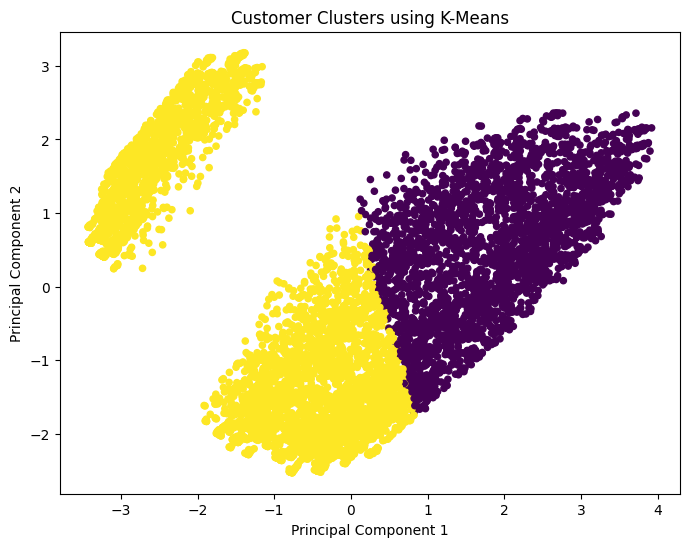

In [71]:



pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=20
)

plt.title("Customer Clusters using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Supervised vs. Unsupervised Learning

The supervised learning approach produced better overall results than the unsupervised approach.

The supervised models achieved higher predictive performance because they were trained using the actual churn labels. During training, the models learned the relationship between customer characteristics and churn status, enabling them to make accurate predictions for new customers.

In contrast, the K-Means clustering algorithm did not use the churn labels. Instead, it grouped customers solely based on similarities in their features. As a result, the generated clusters did not perfectly correspond to customers who churned and those who did not. Although clustering revealed useful patterns in customer behavior, it was not designed to maximize churn prediction accuracy.

Therefore, supervised learning is more suitable for customer churn prediction because the objective is to classify customers into known categories (churn or non-churn). Unsupervised learning is valuable for customer segmentation, discovering hidden patterns, and generating business insights, but it is generally less effective for predicting a predefined target variable.

In conclusion, the supervised approach outperformed the unsupervised approach because it utilized labeled data, allowing it to learn the correct decision boundaries for customer churn prediction.


#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:

# Self Reflection on the Machine Learning Course

This machine learning course provided me with a solid understanding of how data can be transformed into meaningful insights and predictions. Throughout the course, I learned that building a successful machine learning model involves much more than simply choosing an algorithm. It requires careful data preprocessing, feature engineering, model selection, evaluation, and interpretation of results.

## The Easiest Topic: Supervised Learning

The topic I found easiest was **Supervised Learning**, especially classification algorithms such as Logistic Regression, Decision Trees, and Random Forest. I found this topic intuitive because the dataset contains labeled examples, allowing the model to learn the relationship between the input features and the target variable.

A simple real-world example is **email spam detection**. Thousands of emails are already labeled as "Spam" or "Not Spam." By learning from these labeled examples, the model can accurately classify new emails. Similarly, in this project, the model learned from historical customer data to predict whether a customer would churn.

Supervised learning is widely used in many industries, including medical diagnosis, fraud detection, customer churn prediction, sentiment analysis, and recommendation systems. Understanding this topic helped me appreciate how machine learning is applied to solve practical business problems.

## The Hardest Topic: Unsupervised Learning

The most challenging topic for me was **Unsupervised Learning**, particularly clustering algorithms such as K-Means. Unlike supervised learning, unsupervised learning does not have labeled outputs. The algorithm must discover hidden patterns and group similar data points based only on their features.

Initially, it was difficult to understand how to evaluate clustering results because there is no correct answer available during training. Concepts such as choosing the optimal number of clusters, interpreting the Silhouette Score, and validating clustering quality required a deeper understanding.

A real-world example of unsupervised learning is **customer segmentation** in marketing. Companies group customers based on purchasing behavior, age, spending habits, or interests without knowing predefined categories. These groups help businesses design targeted marketing campaigns, personalized recommendations, and customer retention strategies.

Although I initially found unsupervised learning challenging, implementing K-Means clustering in this assignment helped me understand its purpose and limitations. I learned that while clustering can reveal hidden structures in data, it is generally less suitable than supervised learning for predicting a known target such as customer churn.

## Overall Learning Experience

This course has significantly improved my understanding of the complete machine learning workflow. I learned how to preprocess data, select meaningful features, build preprocessing pipelines, train multiple machine learning models, evaluate their performance using appropriate metrics, and compare different approaches.

One of the most valuable lessons I learned is that **the quality of data and preprocessing often has a greater impact on model performance than simply selecting a more complex algorithm**. I also realized the importance of selecting evaluation metrics that match the problem type and interpreting results rather than relying solely on accuracy.

Overall, this course strengthened both my theoretical knowledge and practical implementation skills. It has increased my confidence in applying machine learning techniques to solve real-world problems and has motivated me to continue learning advanced topics such as deep learning, explainable AI, and model deployment.
